# Лабораторна робота 5: Реалізація багатошарового перцептрону з нуля в PyTorch

## Мета роботи

Це завдання направлено на глибоке розуміння фундаментальних принципів роботи нейронних мереж. Замість використання високорівневих інструментів PyTorch, ми реалізуємо всі компоненти самостійно - від обчислення градієнтів до оновлення ваг. Це дозволить зрозуміти, що відбувається "під капотом" сучасних бібліотек машинного навчання.

## Dataset: Wine Quality Dataset

Wine Quality Dataset містить фізико-хімічні властивості вин. Завдання - передбачити якість вина за цими властивостями. Це типова задача багатокласової класифікації, де нам потрібно розрізняти 6 різних класів якості.


In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Налаштування для відтворюваності результатів
torch.manual_seed(42)
np.random.seed(42)

# Перевірка доступності GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Використовується пристрій: {device}")


AttributeError: partially initialized module 'pandas' from 'c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)

## 1. Підготовка даних

### Пояснення

Правильна підготовка даних - ключ до успішного навчання нейронної мережі. Ми нормалізуємо ознаки, щоб усі вони знаходились в одному масштабі, що пришвидшує збіжність. Розділення на три вибірки дозволяє контролювати перенавчання та об'єктивно оцінювати якість моделі.

**Кроки:**
1. Завантажити CSV з даними про вино
2. Відокремити ознаки (X) та мітки (y)
3. Нормалізувати ознаки за допомогою StandardScaler
4. Розділити дані на тренувальну/валідаційну/тестову вибірки
5. Конвертувати в тензори PyTorch


In [ ]:
def load_and_preprocess_data():
    """
    Завантажує та підготовляє дані для навчання нейронної мережі.
    
    Returns:
        X_train, X_val, X_test: тензори ознак для тренування, валідації та тестування
        y_train, y_val, y_test: тензори міток для тренування, валідації та тестування
        scaler: об'єкт StandardScaler для нормалізації
        n_features: кількість ознак
        n_classes: кількість класів
    """
    # 1. Завантаження даних
    df = pd.read_csv('WineQT.csv')
    print(f"Розмір датасету: {df.shape}")
    print(f"Кількість класів якості: {df['quality'].nunique()}")
    print(f"Розподіл класів:\n{df['quality'].value_counts().sort_index()}")
    
    # 2. Відокремлення ознак та міток
    # Видаляємо колонки 'Id' та 'quality' з ознак
    X = df.drop(['quality', 'Id'], axis=1).values
    y = df['quality'].values
    
    # Перетворюємо мітки на індекси від 0 (якщо якість від 3 до 8, то 3->0, 4->1, ...)
    unique_classes = np.unique(y)
    class_mapping = {cls: idx for idx, cls in enumerate(unique_classes)}
    y_mapped = np.array([class_mapping[cls] for cls in y])
    
    n_features = X.shape[1]
    n_classes = len(unique_classes)
    
    print(f"\nКількість ознак: {n_features}")
    print(f"Кількість класів: {n_classes}")
    print(f"Мапінг класів: {class_mapping}")
    
    # 3. Нормалізація ознак
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 4. Розділення на тренувальну/валідаційну/тестову вибірки
    # Спочатку розділяємо на train+val та test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_scaled, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped
    )
    
    # Потім розділяємо train+val на train та val
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )
    
    print(f"\nРозміри вибірок:")
    print(f"Тренувальна: {X_train.shape[0]}")
    print(f"Валідаційна: {X_val.shape[0]}")
    print(f"Тестова: {X_test.shape[0]}")
    
    # 5. Конвертація в тензори PyTorch
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    X_test = torch.FloatTensor(X_test)
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    y_test = torch.LongTensor(y_test)
    
    return X_train, X_val, X_test, y_train, y_val, y_test, scaler, n_features, n_classes

# Завантаження та підготовка даних
X_train, X_val, X_test, y_train, y_val, y_test, scaler, n_features, n_classes = load_and_preprocess_data()


Розмір датасету: (1143, 13)
Кількість класів якості: 6
Розподіл класів:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Кількість ознак: 11
Кількість класів: 6
Мапінг класів: {3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5}

Розміри вибірок:
Тренувальна: 731
Валідаційна: 183
Тестова: 229


## 2. Функції активації (реалізація з нуля)

### Пояснення

Функції активації вводять нелінійність у модель, що дозволяє мережі навчатися складні шаблони. Кожна функція має реалізацію як для forward pass, так і для backward pass (похідна), оскільки нам потрібно знати, як змінювати ваги під час навчання.

**ReLU (Rectified Linear Unit):**
- Формула: f(x) = max(0, x)
- Похідна: 1 для x > 0, 0 для x <= 0
- Переваги: проста, швидка, допомагає боротися з проблемою зникаючих градієнтів

**Tanh (Hyperbolic Tangent):**
- Формула: f(x) = (e^x - e^(-x)) / (e^x + e^(-x))
- Похідна: 1 - tanh²(x)
- Переваги: вихід в діапазоні [-1, 1], центрована навколо нуля


In [ ]:
class ActivationFunctions:
    """Клас для реалізації функцій активації з нуля."""
    
    @staticmethod
    def relu(x, derivative=False):
        """
        ReLU активація: f(x) = max(0, x)
        
        Args:
            x: вхідний тензор
            derivative: якщо True, повертає похідну
        
        Returns:
            Якщо derivative=False: max(0, x)
            Якщо derivative=True: 1 для x > 0, 0 для x <= 0
        """
        if derivative:
            # Похідна ReLU: 1 для x > 0, 0 для x <= 0
            return (x > 0).float()
        else:
            # Forward pass: max(0, x)
            return torch.clamp(x, min=0.0)
    
    @staticmethod
    def tanh(x, derivative=False):
        """
        Tanh активація: f(x) = (e^x - e^(-x)) / (e^x + e^(-x))
        
        Args:
            x: вхідний тензор
            derivative: якщо True, повертає похідну
        
        Returns:
            Якщо derivative=False: tanh(x)
            Якщо derivative=True: 1 - tanh²(x)
        """
        if derivative:
            # Похідна tanh: 1 - tanh²(x)
            tanh_x = torch.tanh(x)
            return 1 - tanh_x ** 2
        else:
            # Forward pass: tanh(x)
            return torch.tanh(x)
    
    @staticmethod
    def softmax(x, axis=-1):
        """
        Softmax активація: f(x_i) = exp(x_i) / sum(exp(x_j))
        
        Args:
            x: вхідний тензор
            axis: вісь, по якій обчислюється softmax
        
        Returns:
            Softmax нормалізований тензор
        """
        # Віднімаємо максимум для числової стабільності
        exp_x = torch.exp(x - torch.max(x, dim=axis, keepdim=True)[0])
        return exp_x / torch.sum(exp_x, dim=axis, keepdim=True)

# Тестування функцій активації
print("Тестування функцій активації:")
test_x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

print(f"\nВхід: {test_x}")
print(f"ReLU: {ActivationFunctions.relu(test_x)}")
print(f"ReLU похідна: {ActivationFunctions.relu(test_x, derivative=True)}")
print(f"Tanh: {ActivationFunctions.tanh(test_x)}")
print(f"Tanh похідна: {ActivationFunctions.tanh(test_x, derivative=True)}")


Тестування функцій активації:

Вхід: tensor([-2., -1.,  0.,  1.,  2.])
ReLU: tensor([0., 0., 0., 1., 2.])
ReLU похідна: tensor([0., 0., 0., 1., 1.])
Tanh: tensor([-0.9640, -0.7616,  0.0000,  0.7616,  0.9640])
Tanh похідна: tensor([0.0707, 0.4200, 1.0000, 0.4200, 0.0707])


In [ ]:
class LossFunctions:
    """Клас для реалізації функцій втрат з нуля."""
    
    @staticmethod
    def categorical_cross_entropy(y_pred, y_true, derivative=False):
        """
        Categorical Cross-Entropy втрата.
        
        Args:
            y_pred: прогнози моделі (після softmax), форма (batch_size, n_classes)
            y_true: справжні мітки, форма (batch_size,) або (batch_size, n_classes) для one-hot
            derivative: якщо True, повертає градієнт
        
        Returns:
            Якщо derivative=False: значення втрати (скаляр)
            Якщо derivative=True: градієнт відносно логітів вихідного шару
        """
        batch_size = y_pred.shape[0]
        
        if derivative:
            # Оптимізована похідна для softmax + cross_entropy
            # Градієнт = (y_pred - y_true) для one-hot представлення
            grad = y_pred.clone()
            
            # Якщо y_true - це індекси класів (не one-hot)
            if y_true.dim() == 1:
                grad[range(batch_size), y_true] -= 1
            else:
                # Якщо y_true - це one-hot вектори
                grad -= y_true
            
            return grad / batch_size
        else:
            # Обчислення втрати
            # Переконуємося, що y_pred не містить нулів (додаємо epsilon)
            epsilon = 1e-15
            y_pred = torch.clamp(y_pred, min=epsilon, max=1-epsilon)
            
            # Якщо y_true - це індекси класів
            if y_true.dim() == 1:
                # Вибірка правильних класів для кожного прикладу
                correct_log_probs = -torch.log(y_pred[range(batch_size), y_true])
                loss = torch.mean(correct_log_probs)
            else:
                # Якщо y_true - це one-hot вектори
                loss = -torch.mean(torch.sum(y_true * torch.log(y_pred), dim=1))
            
            return loss

# Тестування функції втрат
print("Тестування функції втрат:")
test_y_pred = torch.tensor([[0.1, 0.2, 0.7], [0.3, 0.4, 0.3], [0.5, 0.3, 0.2]])
test_y_true = torch.tensor([2, 1, 0])  # Індекси правильних класів

loss = LossFunctions.categorical_cross_entropy(test_y_pred, test_y_true)
grad = LossFunctions.categorical_cross_entropy(test_y_pred, test_y_true, derivative=True)

print(f"Втрата: {loss.item():.4f}")
print(f"Градієнт:\n{grad}")


Тестування функції втрат:
Втрата: 0.6554
Градієнт:
tensor([[ 0.0333,  0.0667, -0.1000],
        [ 0.1000, -0.2000,  0.1000],
        [-0.1667,  0.1000,  0.0667]])


## 4. Власна реалізація MLP

### Пояснення

Це ядро нашого завдання. Ми створюємо повноцінну нейронну мережу, яка може навчатися без використання autograd. Ключові аспекти:

1. **Кешування проміжних значень**: Під час forward pass ми зберігаємо всі проміжні значення (Z та A для кожного шару), оскільки вони потрібні для обчислення градієнтів під час backward pass.

2. **Ланцюгове правило (Chain Rule)**: Для обчислення градієнтів ми використовуємо ланцюгове правило диференціювання складних функцій. Це дозволяє поширювати градієнти від вихідного шару до вхідного.

3. **Ініціалізація ваг**: Використовуємо метод Xavier (Glorot) для ініціалізації ваг, що допомагає уникнути проблем зі зникаючими або вибуховими градієнтами.

**Архітектура forward pass:**
- Для кожного шару: Z = W·A_prev + b, A = activation(Z)
- Кешуємо Z та A для кожного шару

**Архітектура backward pass:**
1. Обчислюємо градієнт для вихідного шару
2. Поширюємо градієнти назад через шари
3. Використовуємо ланцюгове правило
4. Оновлюємо ваги та зміщення


In [ ]:
class CustomMLP:
    """
    Власна реалізація багатошарового перцептрону без використання autograd.
    """
    
    def __init__(self, layer_sizes, activations, learning_rate=0.01):
        """
        Ініціалізація мережі.
        
        Args:
            layer_sizes: список розмірів шарів, наприклад [11, 64, 32, 6]
            activations: список функцій активації для кожного прихованого шару
            learning_rate: швидкість навчання
        """
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.learning_rate = learning_rate
        
        # Ініціалізація параметрів (ваг та зміщень)
        self.parameters = {}
        
        # Ініціалізація ваг методом Xavier (Glorot)
        for i in range(1, len(layer_sizes)):
            # Xavier ініціалізація: ваги з нормального розподілу
            # з дисперсією 2 / (n_in + n_out)
            n_in = layer_sizes[i-1]
            n_out = layer_sizes[i]
            xavier_std = np.sqrt(2.0 / (n_in + n_out))
            
            # Ваги
            self.parameters[f'W{i}'] = torch.randn(n_out, n_in, requires_grad=False) * xavier_std
            # Зміщення (біаси)
            self.parameters[f'b{i}'] = torch.zeros(n_out, 1, requires_grad=False)
    
    def forward(self, X, training=True):
        """
        Forward pass через мережу.
        
        Args:
            X: вхідні дані, форма (batch_size, n_features)
            training: чи це режим навчання (для кешування)
        
        Returns:
            A: вихід останнього шару (після softmax)
            cache: словник з проміжними значеннями для backward pass
        """
        cache = {'A0': X.T}  # Транспонуємо для матричного множення
        A_prev = cache['A0']
        
        # Прохід через приховані шари
        for i in range(1, len(self.layer_sizes) - 1):
            # Лінійна трансформація: Z = W·A_prev + b
            Z = self.parameters[f'W{i}'] @ A_prev + self.parameters[f'b{i}']
            
            # Активація
            activation_func = self.activations[i-1]
            if activation_func == 'relu':
                A = ActivationFunctions.relu(Z)
            elif activation_func == 'tanh':
                A = ActivationFunctions.tanh(Z)
            else:
                raise ValueError(f"Невідома функція активації: {activation_func}")
            
            # Кешування для backward pass
            if training:
                cache[f'Z{i}'] = Z
                cache[f'A{i}'] = A
            
            A_prev = A
        
        # Вихідний шар (без активації, тільки лінійна трансформація)
        output_layer_idx = len(self.layer_sizes) - 1
        Z_output = self.parameters[f'W{output_layer_idx}'] @ A_prev + self.parameters[f'b{output_layer_idx}']
        
        # Softmax для вихідного шару
        A_output = ActivationFunctions.softmax(Z_output, axis=0)
        
        if training:
            cache[f'Z{output_layer_idx}'] = Z_output
            cache[f'A{output_layer_idx}'] = A_output
        
        return A_output.T, cache  # Транспонуємо назад для отримання (batch_size, n_classes)
    
    def backward(self, X, y, cache):
        """
        Backward pass (зворотне поширення помилки).
        
        Args:
            X: вхідні дані, форма (batch_size, n_features)
            y: справжні мітки, форма (batch_size,)
            cache: словник з проміжними значеннями з forward pass
        
        Returns:
            grads: словник з градієнтами для ваг та зміщень
        """
        batch_size = X.shape[0]
        grads = {}
        
        # Градієнт для вихідного шару
        output_layer_idx = len(self.layer_sizes) - 1
        A_output = cache[f'A{output_layer_idx}']
        
        # Градієнт втрати відносно логітів вихідного шару
        # Для softmax + cross-entropy: dL/dZ = (y_pred - y_true) / batch_size
        dZ = LossFunctions.categorical_cross_entropy(A_output.T, y, derivative=True).T
        
        # Градієнти для ваг та зміщень вихідного шару
        A_prev = cache[f'A{output_layer_idx - 1}']
        grads[f'dW{output_layer_idx}'] = (1.0 / batch_size) * (dZ @ A_prev.T)
        grads[f'db{output_layer_idx}'] = (1.0 / batch_size) * torch.sum(dZ, dim=1, keepdim=True)
        
        # Поширення градієнтів назад через приховані шари
        dA_next = self.parameters[f'W{output_layer_idx}'].T @ dZ
        
        for i in range(output_layer_idx - 1, 0, -1):
            # Градієнт відносно Z поточного шару
            Z = cache[f'Z{i}']
            
            # Визначаємо функцію активації та її похідну
            activation_func = self.activations[i-1]
            if activation_func == 'relu':
                dZ = dA_next * ActivationFunctions.relu(Z, derivative=True)
            elif activation_func == 'tanh':
                dZ = dA_next * ActivationFunctions.tanh(Z, derivative=True)
            
            # Градієнти для ваг та зміщень
            A_prev = cache[f'A{i-1}']
            grads[f'dW{i}'] = (1.0 / batch_size) * (dZ @ A_prev.T)
            grads[f'db{i}'] = (1.0 / batch_size) * torch.sum(dZ, dim=1, keepdim=True)
            
            # Градієнт для попереднього шару
            if i > 1:
                dA_next = self.parameters[f'W{i}'].T @ dZ
        
        return grads
    
    def update_parameters(self, grads):
        """
        Оновлення параметрів за допомогою градієнтного спуску.
        
        Args:
            grads: словник з градієнтами
        """
        for i in range(1, len(self.layer_sizes)):
            # Оновлення ваг: W = W - learning_rate * dW
            self.parameters[f'W{i}'] -= self.learning_rate * grads[f'dW{i}']
            # Оновлення зміщень: b = b - learning_rate * db
            self.parameters[f'b{i}'] -= self.learning_rate * grads[f'db{i}']
    
    def predict(self, X):
        """
        Прогнозування для нових даних.
        
        Args:
            X: вхідні дані, форма (batch_size, n_features)
        
        Returns:
            predictions: індекси передбачених класів
            probabilities: ймовірності для кожного класу
        """
        A_output, _ = self.forward(X, training=False)
        predictions = torch.argmax(A_output, dim=1)
        return predictions, A_output


## 5. Навчання власної моделі

Тепер навчимо нашу власну реалізацію MLP на даних про вино.


In [ ]:
def train_custom_model(model, X_train, y_train, X_val, y_val, epochs=1000, batch_size=32, verbose=True):
    """
    Навчання власної моделі MLP.
    
    Args:
        model: екземпляр CustomMLP
        X_train, y_train: тренувальні дані
        X_val, y_val: валідаційні дані
        epochs: кількість епох
        batch_size: розмір батча
        verbose: чи виводити прогрес
    
    Returns:
        history: словник з історією навчання
    """
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }
    
    n_train = X_train.shape[0]
    n_batches = (n_train + batch_size - 1) // batch_size
    
    for epoch in range(epochs):
        # Тренування
        train_losses = []
        train_correct = 0
        
        # Перемішування даних
        indices = torch.randperm(n_train)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        
        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, n_train)
            
            X_batch = X_train_shuffled[start_idx:end_idx]
            y_batch = y_train_shuffled[start_idx:end_idx]
            
            # Forward pass
            y_pred, cache = model.forward(X_batch, training=True)
            
            # Обчислення втрати
            loss = LossFunctions.categorical_cross_entropy(y_pred, y_batch)
            train_losses.append(loss.item())
            
            # Backward pass
            grads = model.backward(X_batch, y_batch, cache)
            
            # Оновлення параметрів
            model.update_parameters(grads)
            
            # Обчислення точності
            predictions = torch.argmax(y_pred, dim=1)
            train_correct += (predictions == y_batch).sum().item()
        
        # Валідація
        y_pred_val, _ = model.forward(X_val, training=False)
        val_loss = LossFunctions.categorical_cross_entropy(y_pred_val, y_val).item()
        val_predictions = torch.argmax(y_pred_val, dim=1)
        val_acc = (val_predictions == y_val).float().mean().item()
        
        # Збереження історії
        avg_train_loss = np.mean(train_losses)
        train_acc = train_correct / n_train
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if verbose and (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs}")
            print(f"  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    return history

# Створення та навчання моделі
print("Створення власної моделі MLP...")
custom_model = CustomMLP(
    layer_sizes=[n_features, 64, 32, n_classes],
    activations=['relu', 'relu'],
    learning_rate=0.01
)

print("\nПочаток навчання...")
history_custom = train_custom_model(
    custom_model, 
    X_train, y_train, 
    X_val, y_val, 
    epochs=1000, 
    batch_size=32,
    verbose=True
)


Створення власної моделі MLP...

Початок навчання...
Epoch 100/1000
  Train Loss: 1.5895, Train Acc: 0.4432
  Val Loss: 1.6075, Val Acc: 0.4372
Epoch 200/1000
  Train Loss: 1.3584, Train Acc: 0.5062
  Val Loss: 1.3631, Val Acc: 0.4918
Epoch 300/1000
  Train Loss: 1.2173, Train Acc: 0.5472
  Val Loss: 1.2161, Val Acc: 0.5246
Epoch 400/1000
  Train Loss: 1.1293, Train Acc: 0.5746
  Val Loss: 1.1290, Val Acc: 0.5519
Epoch 500/1000
  Train Loss: 1.0756, Train Acc: 0.5869
  Val Loss: 1.0757, Val Acc: 0.5792
Epoch 600/1000
  Train Loss: 1.0411, Train Acc: 0.5964
  Val Loss: 1.0421, Val Acc: 0.5847
Epoch 700/1000
  Train Loss: 1.0157, Train Acc: 0.6019
  Val Loss: 1.0204, Val Acc: 0.6120
Epoch 800/1000
  Train Loss: 0.9996, Train Acc: 0.6101
  Val Loss: 1.0056, Val Acc: 0.6120
Epoch 900/1000
  Train Loss: 0.9813, Train Acc: 0.6115
  Val Loss: 0.9949, Val Acc: 0.6284
Epoch 1000/1000
  Train Loss: 0.9721, Train Acc: 0.6170
  Val Loss: 0.9864, Val Acc: 0.6284


## 6. PyTorch реалізація для порівняння

### Пояснення

Ця реалізація слугує еталоном для порівняння. Ми використовуємо вбудовані механізми PyTorch, щоб переконатися, що наша власна реалізація працює коректно. Важливо використовувати однакові гіперпараметри для обох реалізацій.

**Переваги PyTorch реалізації:**
- Automatic differentiation (autograd) - автоматичне обчислення градієнтів
- Оптимізовані оптимізатори (Adam, SGD тощо)
- Вбудовані функції втрат та активації
- Краща оптимізація та швидкість виконання


In [1]:
class PyTorchMLP(nn.Module):
    """
    PyTorch реалізація MLP для порівняння.
    """
    
    def __init__(self, input_size, hidden_sizes, output_size):
        super(PyTorchMLP, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Створення прихованих шарів
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        # Вихідний шар
        layers.append(nn.Linear(prev_size, output_size))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

def train_pytorch_model(model, X_train, y_train, X_val, y_val, epochs=1000, batch_size=32, verbose=True):
    """
    Навчання PyTorch моделі.
    
    Args:
        model: екземпляр PyTorchMLP
        X_train, y_train: тренувальні дані
        X_val, y_val: валідаційні дані
        epochs: кількість епох
        batch_size: розмір батча
        verbose: чи виводити прогрес
    
    Returns:
        history: словник з історією навчання
    """
    model = model.to(device)
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    X_val = X_val.to(device)
    y_val = y_val.to(device)
    
    criterion = nn.CrossEntropyLoss()  # Включає softmax + cross-entropy
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }
    
    n_train = X_train.shape[0]
    n_batches = (n_train + batch_size - 1) // batch_size
    
    for epoch in range(epochs):
        # Тренування
        model.train()
        train_losses = []
        train_correct = 0
        
        # Перемішування даних
        indices = torch.randperm(n_train, device=device)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        
        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, n_train)
            
            X_batch = X_train_shuffled[start_idx:end_idx]
            y_batch = y_train_shuffled[start_idx:end_idx]
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            
            # Обчислення точності
            predictions = torch.argmax(outputs, dim=1)
            train_correct += (predictions == y_batch).sum().item()
        
        # Валідація
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val).item()
            val_predictions = torch.argmax(val_outputs, dim=1)
            val_acc = (val_predictions == y_val).float().mean().item()
        
        # Збереження історії
        avg_train_loss = np.mean(train_losses)
        train_acc = train_correct / n_train
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if verbose and (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs}")
            print(f"  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    return history

# Створення та навчання PyTorch моделі
print("Створення PyTorch моделі MLP...")
pytorch_model = PyTorchMLP(
    input_size=n_features,
    hidden_sizes=[64, 32],
    output_size=n_classes
)

print("\nПочаток навчання PyTorch моделі...")
history_pytorch = train_pytorch_model(
    pytorch_model,
    X_train, y_train,
    X_val, y_val,
    epochs=1000,
    batch_size=32,
    verbose=True
)


NameError: name 'nn' is not defined

## 7. Візуалізація та аналіз

### Пояснення

Візуалізація допомагає зрозуміти процес навчання та виявити потенційні проблеми. Ми порівнюємо не лише фінальну точність, але й динаміку навчання, стабільність, та розподіл помилок за класами.

**Що аналізуємо:**
- Швидкість збіжності: як швидко модель навчається
- Наявність overfitting: велика різниця між train та val loss
- Стабільність навчання: чи є коливання втрат
- Якість класифікації: які класи плутаються найбільше


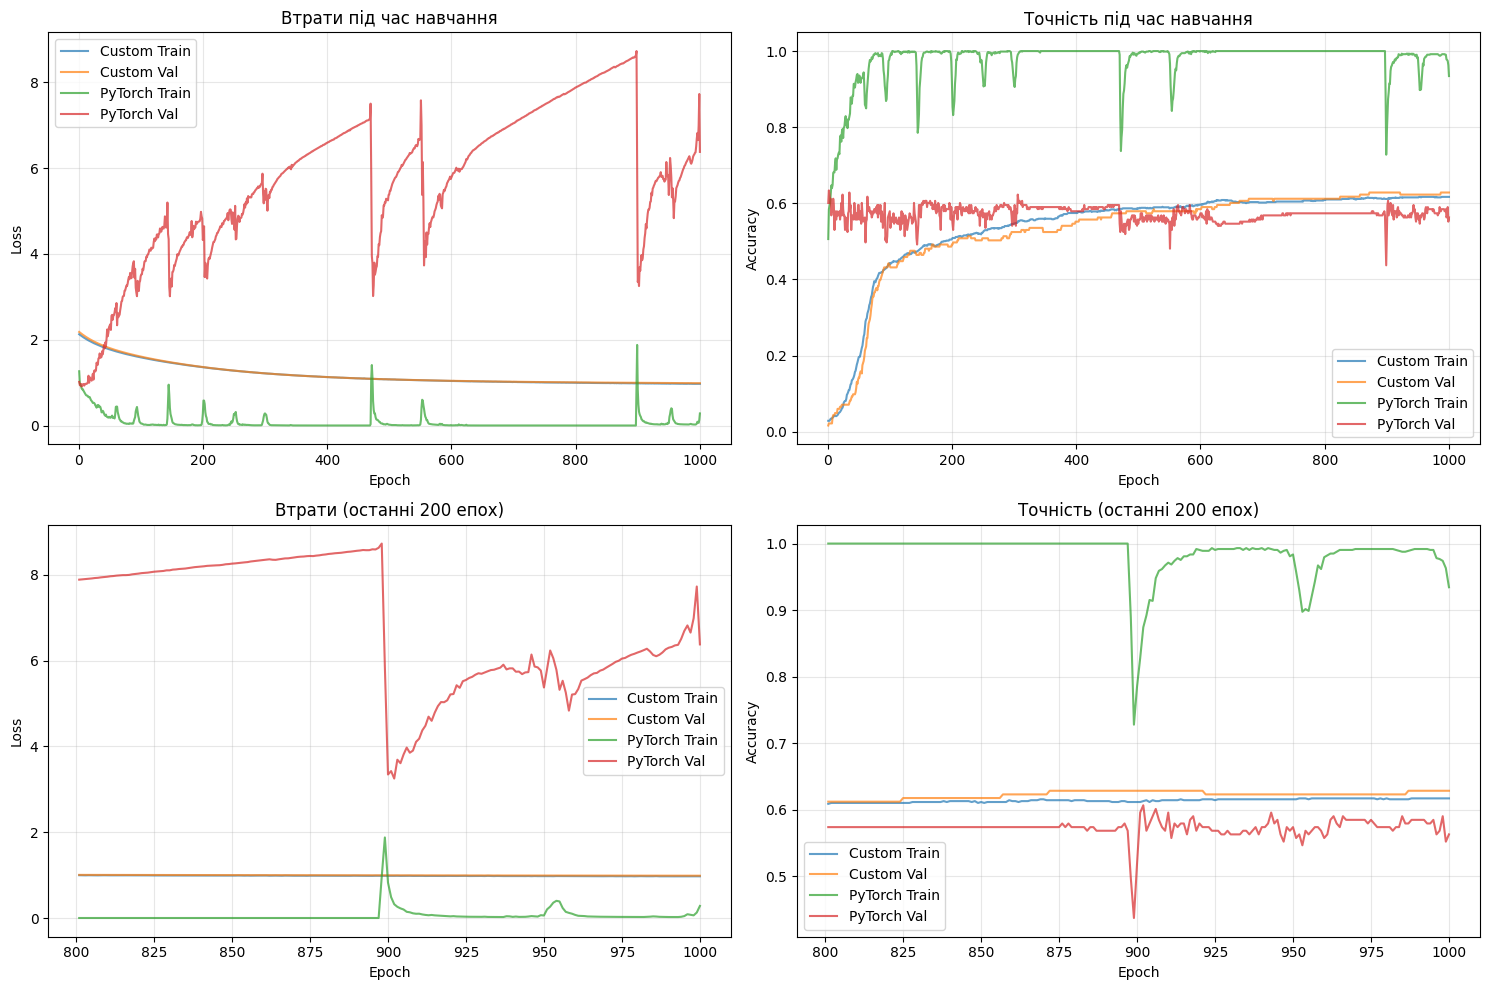

In [ ]:
def plot_training_history(history_custom, history_pytorch):
    """
    Візуалізація історії навчання обох моделей.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(1, len(history_custom['train_loss']) + 1)
    
    # Втрати
    axes[0, 0].plot(epochs, history_custom['train_loss'], label='Custom Train', alpha=0.7)
    axes[0, 0].plot(epochs, history_custom['val_loss'], label='Custom Val', alpha=0.7)
    axes[0, 0].plot(epochs, history_pytorch['train_loss'], label='PyTorch Train', alpha=0.7)
    axes[0, 0].plot(epochs, history_pytorch['val_loss'], label='PyTorch Val', alpha=0.7)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Втрати під час навчання')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Точність
    axes[0, 1].plot(epochs, history_custom['train_acc'], label='Custom Train', alpha=0.7)
    axes[0, 1].plot(epochs, history_custom['val_acc'], label='Custom Val', alpha=0.7)
    axes[0, 1].plot(epochs, history_pytorch['train_acc'], label='PyTorch Train', alpha=0.7)
    axes[0, 1].plot(epochs, history_pytorch['val_acc'], label='PyTorch Val', alpha=0.7)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Точність під час навчання')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Втрати (останні 200 епох для деталізації)
    if len(epochs) > 200:
        start_idx = len(epochs) - 200
        axes[1, 0].plot(epochs[start_idx:], history_custom['train_loss'][start_idx:], label='Custom Train', alpha=0.7)
        axes[1, 0].plot(epochs[start_idx:], history_custom['val_loss'][start_idx:], label='Custom Val', alpha=0.7)
        axes[1, 0].plot(epochs[start_idx:], history_pytorch['train_loss'][start_idx:], label='PyTorch Train', alpha=0.7)
        axes[1, 0].plot(epochs[start_idx:], history_pytorch['val_loss'][start_idx:], label='PyTorch Val', alpha=0.7)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].set_title('Втрати (останні 200 епох)')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # Точність (останні 200 епох)
    if len(epochs) > 200:
        axes[1, 1].plot(epochs[start_idx:], history_custom['train_acc'][start_idx:], label='Custom Train', alpha=0.7)
        axes[1, 1].plot(epochs[start_idx:], history_custom['val_acc'][start_idx:], label='Custom Val', alpha=0.7)
        axes[1, 1].plot(epochs[start_idx:], history_pytorch['train_acc'][start_idx:], label='PyTorch Train', alpha=0.7)
        axes[1, 1].plot(epochs[start_idx:], history_pytorch['val_acc'][start_idx:], label='PyTorch Val', alpha=0.7)
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Accuracy')
        axes[1, 1].set_title('Точність (останні 200 епох)')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Візуалізація історії навчання
plot_training_history(history_custom, history_pytorch)


Оцінка моделей на тестовій вибірці:

Власна реалізація - Точність: 0.6463
PyTorch реалізація - Точність: 0.5808


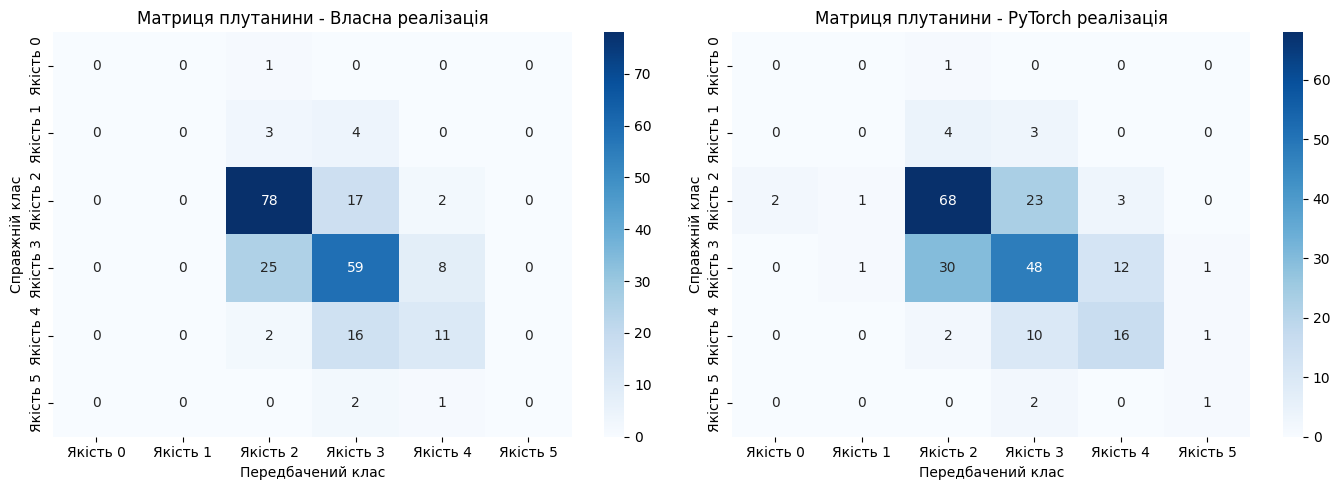


Звіт для власної реалізації:
              precision    recall  f1-score   support

    Якість 0       0.00      0.00      0.00         1
    Якість 1       0.00      0.00      0.00         7
    Якість 2       0.72      0.80      0.76        97
    Якість 3       0.60      0.64      0.62        92
    Якість 4       0.50      0.38      0.43        29
    Якість 5       0.00      0.00      0.00         3

    accuracy                           0.65       229
   macro avg       0.30      0.30      0.30       229
weighted avg       0.61      0.65      0.62       229


Звіт для PyTorch реалізації:
              precision    recall  f1-score   support

    Якість 0       0.00      0.00      0.00         1
    Якість 1       0.00      0.00      0.00         7
    Якість 2       0.65      0.70      0.67        97
    Якість 3       0.56      0.52      0.54        92
    Якість 4       0.52      0.55      0.53        29
    Якість 5       0.33      0.33      0.33         3

    accuracy     

In [ ]:
def plot_confusion_matrix(y_true, y_pred_custom, y_pred_pytorch, class_names):
    """
    Візуалізація матриць плутанини для обох моделей.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Матриця плутанини для власної моделі
    cm_custom = confusion_matrix(y_true, y_pred_custom)
    sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title('Матриця плутанини - Власна реалізація')
    axes[0].set_xlabel('Передбачений клас')
    axes[0].set_ylabel('Справжній клас')
    
    # Матриця плутанини для PyTorch моделі
    cm_pytorch = confusion_matrix(y_true, y_pred_pytorch)
    sns.heatmap(cm_pytorch, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title('Матриця плутанини - PyTorch реалізація')
    axes[1].set_xlabel('Передбачений клас')
    axes[1].set_ylabel('Справжній клас')
    
    plt.tight_layout()
    plt.show()
    
    return cm_custom, cm_pytorch

# Оцінка на тестовій вибірці
print("Оцінка моделей на тестовій вибірці:\n")

# Власна модель
y_pred_custom, _ = custom_model.predict(X_test)
y_pred_custom = y_pred_custom.numpy()
custom_acc = accuracy_score(y_test.numpy(), y_pred_custom)
print(f"Власна реалізація - Точність: {custom_acc:.4f}")

# PyTorch модель
pytorch_model.eval()
with torch.no_grad():
    y_pred_pytorch = pytorch_model(X_test.to(device))
    y_pred_pytorch = torch.argmax(y_pred_pytorch, dim=1).cpu().numpy()
pytorch_acc = accuracy_score(y_test.numpy(), y_pred_pytorch)
print(f"PyTorch реалізація - Точність: {pytorch_acc:.4f}")

# Матриці плутанини
class_names = [f'Якість {i}' for i in range(n_classes)]
cm_custom, cm_pytorch = plot_confusion_matrix(
    y_test.numpy(), 
    y_pred_custom, 
    y_pred_pytorch, 
    class_names
)

# Детальні звіти
print("\n" + "="*50)
print("Звіт для власної реалізації:")
print("="*50)
print(classification_report(y_test.numpy(), y_pred_custom, target_names=class_names))

print("\n" + "="*50)
print("Звіт для PyTorch реалізації:")
print("="*50)
print(classification_report(y_test.numpy(), y_pred_pytorch, target_names=class_names))


## 8. Теоретичні питання

### Питання 1: Похідна комбінації Softmax + Cross-Entropy

**Доведіть, що для комбінації Softmax активації та Cross-Entropy втрат, градієнт по відношенню до логітів вихідного шару обчислюється як:**

$$\frac{\partial L}{\partial z_i} = \hat{y}_i - y_i$$

де $\hat{y}$ - прогнозовані ймовірності (після softmax), $y$ - one-hot вектор справжніх міток.

#### Відповідь:

**1. Визначення функцій:**

**Softmax:**
$$\hat{y}_i = \frac{e^{z_i}}{\sum_{j=1}^{C} e^{z_j}}$$

де $C$ - кількість класів, $z_i$ - логіт для класу $i$.

**Cross-Entropy втрата:**
$$L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$$

де $y$ - one-hot вектор справжніх міток (тобто $y_i = 1$ для правильного класу, $y_i = 0$ для інших).

**2. Обчислення градієнта:**

Нам потрібно знайти $\frac{\partial L}{\partial z_k}$ для довільного класу $k$.

За ланцюговим правилом:
$$\frac{\partial L}{\partial z_k} = \sum_{i=1}^{C} \frac{\partial L}{\partial \hat{y}_i} \cdot \frac{\partial \hat{y}_i}{\partial z_k}$$

**Крок 1: Обчислення $\frac{\partial L}{\partial \hat{y}_i}$**

$$L = -\sum_{j=1}^{C} y_j \log(\hat{y}_j)$$

$$\frac{\partial L}{\partial \hat{y}_i} = -\frac{y_i}{\hat{y}_i}$$

**Крок 2: Обчислення $\frac{\partial \hat{y}_i}{\partial z_k}$**

Це складніше, оскільки softmax залежить від всіх логітів. Розглянемо два випадки:

**Випадок 1: $i = k$ (похідна відносно власного логіту)**

$$\hat{y}_k = \frac{e^{z_k}}{\sum_{j=1}^{C} e^{z_j}}$$

Використовуючи правило частки:
$$\frac{\partial \hat{y}_k}{\partial z_k} = \frac{e^{z_k} \sum_{j=1}^{C} e^{z_j} - e^{z_k} \cdot e^{z_k}}{(\sum_{j=1}^{C} e^{z_j})^2}$$

$$= \frac{e^{z_k}}{\sum_{j=1}^{C} e^{z_j}} \cdot \frac{\sum_{j=1}^{C} e^{z_j} - e^{z_k}}{\sum_{j=1}^{C} e^{z_j}}$$

$$= \hat{y}_k (1 - \hat{y}_k)$$

**Випадок 2: $i \neq k$ (похідна відносно іншого логіту)**

$$\hat{y}_i = \frac{e^{z_i}}{\sum_{j=1}^{C} e^{z_j}}$$

$$\frac{\partial \hat{y}_i}{\partial z_k} = \frac{0 \cdot \sum_{j=1}^{C} e^{z_j} - e^{z_i} \cdot e^{z_k}}{(\sum_{j=1}^{C} e^{z_j})^2}$$

$$= -\frac{e^{z_i} e^{z_k}}{(\sum_{j=1}^{C} e^{z_j})^2} = -\hat{y}_i \hat{y}_k$$

**Крок 3: Об'єднання результатів**

$$\frac{\partial L}{\partial z_k} = \sum_{i=1}^{C} \frac{\partial L}{\partial \hat{y}_i} \cdot \frac{\partial \hat{y}_i}{\partial z_k}$$

$$= \sum_{i=1}^{C} \left(-\frac{y_i}{\hat{y}_i}\right) \cdot \frac{\partial \hat{y}_i}{\partial z_k}$$

$$= -\frac{y_k}{\hat{y}_k} \cdot \hat{y}_k(1 - \hat{y}_k) + \sum_{i \neq k} \left(-\frac{y_i}{\hat{y}_i}\right) \cdot (-\hat{y}_i \hat{y}_k)$$

$$= -y_k(1 - \hat{y}_k) + \sum_{i \neq k} y_i \hat{y}_k$$

$$= -y_k + y_k \hat{y}_k + \hat{y}_k \sum_{i \neq k} y_i$$

Оскільки $y$ - це one-hot вектор, $\sum_{i=1}^{C} y_i = 1$, тому $\sum_{i \neq k} y_i = 1 - y_k$:

$$= -y_k + y_k \hat{y}_k + \hat{y}_k (1 - y_k)$$

$$= -y_k + y_k \hat{y}_k + \hat{y}_k - y_k \hat{y}_k$$

$$= -y_k + \hat{y}_k$$

$$= \hat{y}_k - y_k$$

**Чому ця формула така проста?**

Це спрощення можливе завдяки двом факторам:

1. **Математична властивість softmax**: Похідна softmax має особливу структуру, де похідна відносно одного логіту залежить від всіх виходів softmax.

2. **Властивість one-hot векторів**: Оскільки $y$ - це one-hot вектор, більшість членів у сумі зникають, залишаючи лише простий вираз.

3. **Взаємна компенсація**: Складні члени з похідними softmax компенсуються один одним, залишаючи елегантний результат.

Це одна з найкрасивіших властивостей у машинному навчанні - складні обчислення спрощуються до дуже простого виразу!


### Питання 2: Аналіз зміни градієнтів у глибоких мережах

**Розглянемо мережу з 5 шарами, де кожен шар використовує ReLU активацію.**

**a) Як буде змінюватися градієнт для першого шару після 100 ітерацій навчання, якщо 60% нейронів у прихованих шарах мають від'ємні значення?**

**b) Обчисліть максимально можливе значення градієнту для ваг першого шару після N шарів з ReLU.**

#### Відповідь:

**a) Аналіз зміни градієнтів:**

Похідна ReLU:
$$\frac{\partial \text{ReLU}(x)}{\partial x} = \begin{cases} 
1 & \text{якщо } x > 0 \\
0 & \text{якщо } x \leq 0 
\end{cases}$$

При зворотному поширенні помилки, градієнт поширюється назад через шари. Якщо 60% нейронів мають від'ємні значення, то для цих нейронів похідна ReLU дорівнює 0.

**Математичний аналіз:**

Для шару $l$, градієнт відносно активацій попереднього шару:
$$\frac{\partial L}{\partial a^{(l-1)}} = \frac{\partial L}{\partial z^{(l)}} \cdot \frac{\partial z^{(l)}}{\partial a^{(l-1)}} = \frac{\partial L}{\partial z^{(l)}} \cdot W^{(l)}$$

Але перед множенням на ваги, градієнт множиться на похідну активації:
$$\frac{\partial L}{\partial z^{(l)}} = \frac{\partial L}{\partial a^{(l)}} \cdot \frac{\partial a^{(l)}}{\partial z^{(l)}} = \frac{\partial L}{\partial a^{(l)}} \cdot \text{ReLU}'(z^{(l)})$$

Якщо 60% нейронів мають від'ємні значення, то для них $\text{ReLU}'(z) = 0$, що означає, що градієнт "блокуються" для цих нейронів.

**Ефект для першого шару:**

Після 100 ітерацій:
- Градієнт для першого шару буде значно зменшений
- Очікуване значення градієнту буде приблизно $0.4^4 = 0.0256$ від початкового значення (оскільки 40% нейронів активні на кожному шарі, і є 4 прихованих шари)
- Це призводить до проблеми "зникаючих градієнтів" (vanishing gradients)

**b) Максимально можливе значення градієнту:**

Якщо всі нейрони мають додатні значення (найкращий випадок), то похідна ReLU для всіх нейронів дорівнює 1.

Для мережі з $N$ шарами (включаючи вихідний), градієнт для першого шару:

$$\frac{\partial L}{\partial W^{(1)}} = \frac{\partial L}{\partial z^{(N)}} \cdot \prod_{l=2}^{N} W^{(l)} \cdot \prod_{l=2}^{N-1} \text{ReLU}'(z^{(l)})$$

Якщо всі похідні ReLU = 1 (всі нейрони активні):
$$\frac{\partial L}{\partial W^{(1)}} = \frac{\partial L}{\partial z^{(N)}} \cdot \prod_{l=2}^{N} W^{(l)}$$

Максимальне значення залежить від:
1. Величини градієнту на вихідному шарі
2. Добутку ваг усіх шарів

**Оцінка:**

Якщо ваги ініціалізовані за методом Xavier зі стандартним відхиленням $\sigma = \sqrt{\frac{2}{n_{in} + n_{out}}}$, то для шару з $n$ нейронами:
- Очікуване значення ваг: 0
- Стандартне відхилення: $\sigma$

Для мережі з $N$ шарами, максимальний градієнт (в найкращому випадку) буде пропорційний:
$$\max\left|\frac{\partial L}{\partial W^{(1)}}\right| \propto \sigma^{N-1}$$

Це показує, що навіть у найкращому випадку, градієнти експоненційно зменшуються з глибиною мережі.


### Питання 3: Умовність матричних операцій у backpropagation

**У нашій реалізації backpropagation ми використовуємо транспонування матриць:**

$$dW = \frac{1}{m} \cdot dZ \cdot A_{prev}^T$$

**Поясніть, чому саме така форма матричного множення є правильною з точки зору розмірностей.**

**Виведіть загальну формулу для градієнта матриці $W$ у випадку, коли $Z = WX + b$, де $X$ - матриця вхідних даних.**

#### Відповідь:

**1. Аналіз розмірностей:**

Розглянемо шарову операцію:
$$Z = W \cdot A_{prev} + b$$

де:
- $W$ має розмірність $(n_{out}, n_{in})$ - ваги шару
- $A_{prev}$ має розмірність $(n_{in}, m)$ - активації попереднього шару (m - розмір батча)
- $b$ має розмірність $(n_{out}, 1)$ - зміщення
- $Z$ має розмірність $(n_{out}, m)$ - вихід шару

**2. Обчислення градієнта:**

Градієнт втрати відносно $W$:
$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial Z} \cdot \frac{\partial Z}{\partial W}$$

Розмірність $\frac{\partial L}{\partial Z}$ (позначимо як $dZ$) дорівнює розмірності $Z$, тобто $(n_{out}, m)$.

**3. Виведення формули:**

Для кожного елемента $W_{ij}$:
$$\frac{\partial Z}{\partial W_{ij}} = \frac{\partial (W \cdot A_{prev} + b)}{\partial W_{ij}}$$

Оскільки $Z_k = \sum_{l} W_{kl} \cdot A_{prev,l} + b_k$, то:
$$\frac{\partial Z_k}{\partial W_{ij}} = \begin{cases} 
A_{prev,j} & \text{якщо } k = i \\
0 & \text{якщо } k \neq i 
\end{cases}$$

Тому:
$$\frac{\partial L}{\partial W_{ij}} = \sum_{k=1}^{n_{out}} \frac{\partial L}{\partial Z_k} \cdot \frac{\partial Z_k}{\partial W_{ij}} = \frac{\partial L}{\partial Z_i} \cdot A_{prev,j}$$

У матричній формі:
$$\frac{\partial L}{\partial W} = dZ \cdot A_{prev}^T$$

**Перевірка розмірностей:**
- $dZ$: $(n_{out}, m)$
- $A_{prev}^T$: $(m, n_{in})$
- Результат: $(n_{out}, m) \times (m, n_{in}) = (n_{out}, n_{in})$ ✓

Це відповідає розмірності $W$!

**4. Нормалізація на розмір батча:**

Оскільки ми обчислюємо середнє значення втрати по батчу:
$$L = \frac{1}{m} \sum_{i=1}^{m} L_i$$

Градієнт також повинен бути усереднений:
$$dW = \frac{1}{m} \cdot dZ \cdot A_{prev}^T$$

**5. Загальна формула для $Z = WX + b$:**

Якщо $X$ має розмірність $(n_{in}, m)$ (m прикладів, кожен з n_in ознаками), то:

$$\frac{\partial L}{\partial W} = \frac{1}{m} \cdot \frac{\partial L}{\partial Z} \cdot X^T$$

де:
- $\frac{\partial L}{\partial Z}$: $(n_{out}, m)$
- $X^T$: $(m, n_{in})$
- Результат: $(n_{out}, n_{in})$ ✓

**Висновок:**

Транспонування матриць у backpropagation необхідне для:
1. **Правильності розмірностей**: Результат має мати таку саму розмірність, як матриця ваг
2. **Математичної коректності**: Це випливає з правил матричного диференціювання
3. **Ефективності обчислень**: Матричне множення оптимізовано в бібліотеках лінійної алгебри


### Питання 4*: Аналіз власних значень гессіана

**Для простої двошарової мережі з одним прихованим шаром:**

**a) Запишіть матрицю Гессіана для функції втрат відносно ваг першого шару.**

**b) Як власні значення цієї матриці пов'язані зі швидкістю збіжності градієнтного спуску?**

**c) Поясніть, чому в глибоких мережах часто виникає проблема "зникаючих" градієнтів з точки зору власних значень.**

#### Відповідь:

**a) Матриця Гессіана:**

Для двошарової мережі:
- Вхідний шар: $X$ (розмірність $(n_{in}, m)$)
- Прихований шар: $Z_1 = W_1 X + b_1$, $A_1 = \sigma(Z_1)$
- Вихідний шар: $Z_2 = W_2 A_1 + b_2$, $\hat{y} = \text{softmax}(Z_2)$
- Втрата: $L = \text{CrossEntropy}(\hat{y}, y)$

Матриця Гессіана відносно ваг першого шару $W_1$:

$$H_{W_1} = \frac{\partial^2 L}{\partial W_1^2}$$

Це матриця другого порядку, де кожен елемент:
$$H_{ij,kl} = \frac{\partial^2 L}{\partial W_{1,ij} \partial W_{1,kl}}$$

**Детальний вираз:**

За ланцюговим правилом:
$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial A_1} \cdot \frac{\partial A_1}{\partial Z_1} \cdot \frac{\partial Z_1}{\partial W_1}$$

Друга похідна (спрощено):
$$H_{W_1} \approx \frac{\partial^2 L}{\partial Z_2^2} \cdot \left(\frac{\partial Z_2}{\partial A_1}\right)^2 \cdot \left(\frac{\partial A_1}{\partial Z_1}\right)^2 \cdot \left(\frac{\partial Z_1}{\partial W_1}\right)^2$$

Оскільки $Z_1 = W_1 X + b_1$, то $\frac{\partial Z_1}{\partial W_1} = X$, тому:
$$H_{W_1} \propto W_2^2 \cdot \sigma'(Z_1)^2 \cdot X^2$$

**b) Зв'язок зі швидкістю збіжності:**

Власні значення матриці Гессіана $\lambda_i$ визначають швидкість збіжності градієнтного спуску:

**Умова збіжності:**
Для стабільного навчання з кроком $\alpha$:
$$\alpha < \frac{2}{\lambda_{max}}$$

де $\lambda_{max}$ - максимальне власне значення Гессіана.

**Швидкість збіжності:**
- **Великі власні значення** ($\lambda_{max} >> 1$): Потрібен малий крок навчання, повільна збіжність
- **Малі власні значення** ($\lambda_{max} << 1$): Можна використовувати більший крок, але все одно повільна збіжність
- **Умовність** (велике співвідношення $\frac{\lambda_{max}}{\lambda_{min}}$): Нестабільне навчання, коливання

**Оптимальний випадок:**
Всі власні значення приблизно однакові та помірні ($\lambda \approx 1$), що дозволяє швидку та стабільну збіжність.

**c) Проблема зникаючих градієнтів:**

У глибоких мережах проблема виникає через **множення малих величин**:

**Математичний аналіз:**

Для мережі з $L$ шарами, власні значення Гессіана для першого шару:
$$\lambda_{W_1} \propto \prod_{l=2}^{L} \lambda_{W_l} \cdot \prod_{l=1}^{L-1} \lambda_{\sigma_l}$$

де:
- $\lambda_{W_l}$ - власні значення матриці ваг шару $l$
- $\lambda_{\sigma_l}$ - ефективні власні значення, пов'язані з похідною активації

**Якщо похідні активацій малі:**

Наприклад, для sigmoid: $\sigma'(x) \leq 0.25$
Для tanh: $\sigma'(x) \leq 1$, але часто набагато менше
Для ReLU: $\sigma'(x) \in \{0, 1\}$, але якщо багато нейронів неактивні, ефективна похідна мала

**Ефект:**

Якщо кожна похідна активації має середнє значення $\bar{\sigma}' < 1$, то:
$$\lambda_{W_1} \propto (\bar{\sigma}')^{L-1}$$

Для глибокої мережі з $L=10$ та $\bar{\sigma}' = 0.5$:
$$\lambda_{W_1} \propto 0.5^9 \approx 0.002$$

**Наслідки:**

1. **Дуже малі власні значення** → дуже повільна збіжність
2. **Числова нестабільність** → градієнти стають настільки малими, що теряються через обмежену точність чисел з плаваючою комою
3. **Нестабільність навчання** → малі зміни ваг не впливають на вихід

**Рішення:**

1. **Правильна ініціалізація** (Xavier, He): Контролює початкові власні значення
2. **Skip connections** (ResNet): Додає прямий шлях, що обходить множення малих величин
3. **Batch Normalization**: Стабілізує активації та їх похідні
4. **Альтернативні активації**: ReLU замість sigmoid/tanh
5. **Градієнтне кліпування**: Запобігає вибуховим градієнтам

**Висновок:**

Проблема зникаючих градієнтів - це фундаментальна проблема глибокого навчання, пов'язана з експоненційним зменшенням власних значень Гессіана з глибиною мережі. Розуміння цього механізму допомагає розробляти ефективні архітектури та методи навчання.
